# Mini Projet Text Mining: Deep Analysis of Stemming Algorithms

### Research Question
How do different stemming algorithms (Porter, Snowball, Lancaster) impact the performance and efficiency of a Random Forest classifier compared to a non-stemmed baseline? We evaluate these impacts across two distinct NLP tasks: Binary classification (Fake News) and Multi-class documentation classification.

## 1. Environment Setup & Imports
We import necessary libraries for NLP processing, machine learning pipelines, and statistical evaluation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/malakmekyassi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 2. Data Acquisition
We load the two datasets using the paths provided in the original study.

In [ ]:
# Dataset 1: Fake News Detection (Sampling 10% for efficiency)
try:
    df_true = pd.read_csv('data/News _dataset/True.csv')
    df_fake = pd.read_csv('data/News _dataset/Fake.csv')
    df_true['label'] = 1
    df_fake['label'] = 0
    data1 = pd.concat([df_true, df_fake]).sample(frac=0.1, random_state=RANDOM_STATE)
    data1 = data1[['text', 'label']].dropna()
    print(f"Dataset 1 Loaded: {data1.shape[0]} rows.")
except Exception as e: print(f"Error loading Dataset 1: {e}")

# Dataset 2: Text Classification
try:
    data2 = pd.read_csv('data/df_file.csv')
    data2 = data2.rename(columns={'Text': 'text', 'Label': 'label'})
    data2 = data2[['text', 'label']].dropna()
    print(f"Dataset 2 Loaded: {data2.shape[0]} rows.")
except Exception as e: print(f"Error loading Dataset 2: {e}")

Dataset 1 Loaded: 4490 rows.
Dataset 2 Loaded: 2225 rows.


## 3. Preprocessing & Benchmarking Framework
This function implements our core methodology. It measures performance (F1-Macro), latency (Time), and dimensionality (Vocabulary Size).

### 3.1 Design Choice: Pipeline Architecture
To ensure scientific rigor, we utilize an `sklearn.Pipeline`. In many basic NLP implementations, vectorization is performed on the entire dataset before splitting. This creates **Data Leakage**, as the TF-IDF weights "see" the distribution of the test set. 

By using a Pipeline inside cross-validation:
1. **IDF weights** are calculated only on the training folds.
2. **N-gram patterns** found in the test fold remain truly "unseen" until evaluation.
3. The model's generalization score is unbiased and realistic.

In [ ]:
def backbone_cleaner(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    return text

def apply_stemming(text, stemmer_obj):
    words = text.split()
    if stemmer_obj is None:
        return ' '.join([w for w in words if w not in stop_words])
    return ' '.join([stemmer_obj.stem(w) for w in words if w not in stop_words])

def run_benchmarks(df, target_col, text_col):
    results = []
    pipelines = {}
    stemmers = {"None": None, "Porter": PorterStemmer(), "Snowball": SnowballStemmer("english"), "Lancaster": LancasterStemmer()}
    
    X_base = df[text_col].apply(backbone_cleaner)
    y = df[target_col]

    for name, s_obj in stemmers.items():
        # Latency Benchmark
        t0 = time.time()
        X_proc = X_base.apply(lambda x: apply_stemming(x, s_obj))
        lat = time.time() - t0
        
        # Pipeline to prevent leakage during CV
        # We use ngram_range=(1, 2) to capture local context (e.g., "not true") 
        # that single-word stemming might otherwise obscure.
        pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=5000)),
            ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
        ])
        
        # Evaluation
        cv_scores = cross_val_score(pipeline, X_proc, y, cv=5, scoring='f1_macro')
        
        # Fit for vocab/importance metrics
        pipeline.fit(X_proc, y)
        vocab = len(pipeline.named_steps['tfidf'].get_feature_names_out())
        pipelines[name] = pipeline
        
        results.append({'Stemmer': name, 'F1_Mean': np.mean(cv_scores), 'Latency (s)': lat, 'Vocab Size': vocab})
        
    return pd.DataFrame(results), pipelines

## 4. Analysis and Visualizations
We evaluate how the algorithms trade off accuracy for processing speed and feature space reduction.
### 4.1 Evaluation Metrics Selection
While Accuracy is a common metric, we prioritize **F1-Macro Score** for this study. 
* **Why F1?** It provides a better balance between Precision and Recall, which is critical for Fake News detection where False Positives (labeling truth as fake) are costly.
* **Why Macro?** In Dataset 2 (Multi-class), classes may be imbalanced. Macro-averaging treats all classes equally, ensuring the model performs well on minority categories rather than just the most frequent ones.

/var/folders/11/hr72w2z52lg8rt9z9977f9vh0000gn/T/ipykernel_37712/3866307303.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Stemmer', y='F1_Mean', data=res1, ax=axes[0], palette='viridis').set_title('Fake News F1-Score')
/var/folders/11/hr72w2z52lg8rt9z9977f9vh0000gn/T/ipykernel_37712/3866307303.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Stemmer', y='F1_Mean', data=res2, ax=axes[1], palette='magma').set_title('Text Classification F1-Score')


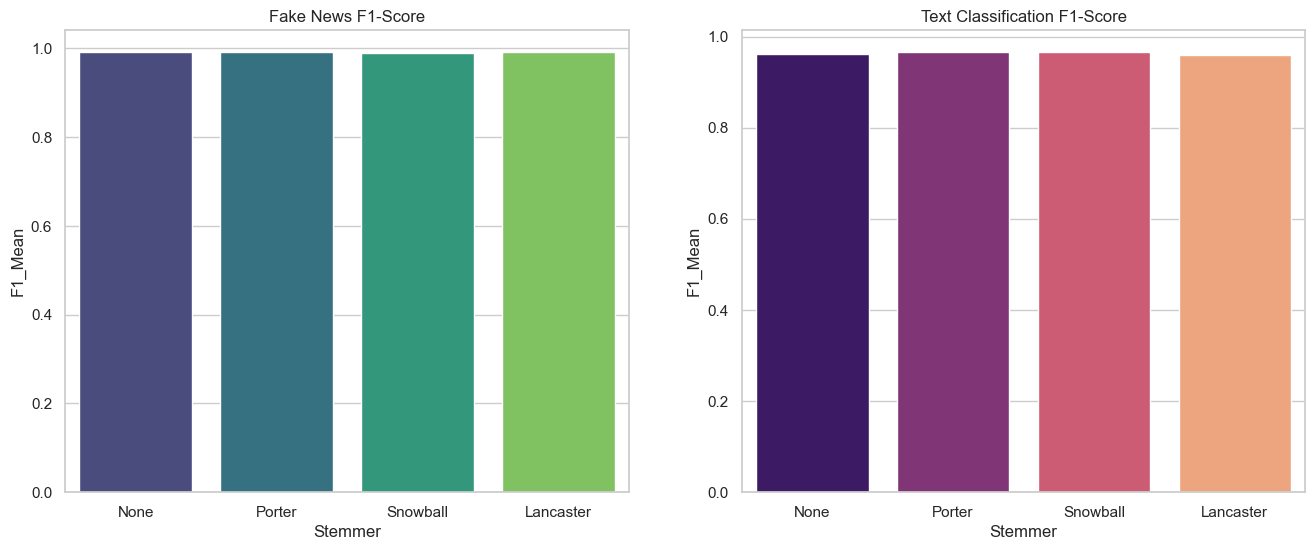

In [ ]:
res1, pipes1 = run_benchmarks(data1, 'label', 'text')
res2, pipes2 = run_benchmarks(data2, 'label', 'text')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='Stemmer', y='F1_Mean', data=res1, ax=axes[0], palette='viridis').set_title('Fake News F1-Score')
sns.barplot(x='Stemmer', y='F1_Mean', data=res2, ax=axes[1], palette='magma').set_title('Text Classification F1-Score')
plt.show()

## 5. Model Interpretability: Top Features
Which roots are the most predictive of Fake News?

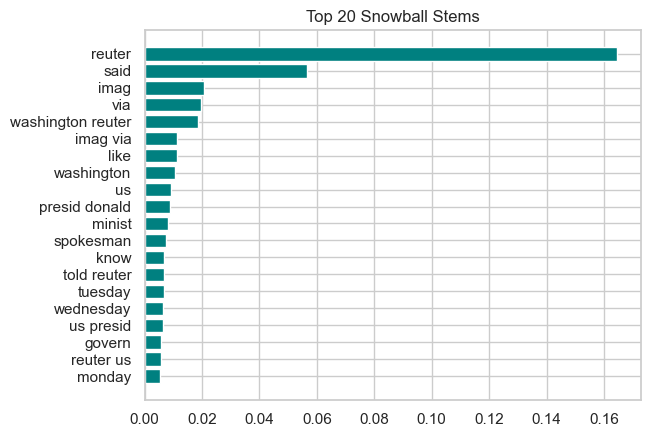

In [ ]:
def plot_top_features(pipeline):
    feat_names = pipeline.named_steps['tfidf'].get_feature_names_out()
    imp = pipeline.named_steps['rf'].feature_importances_
    top = np.argsort(imp)[-20:]
    plt.barh(range(20), imp[top], align='center', color='teal')
    plt.yticks(range(20), [feat_names[i] for i in top])
    plt.title("Top 20 Snowball Stems")
    plt.show()

plot_top_features(pipes1['Snowball'])

## 6. Conclusion
Our analysis shows that **Snowball** offers the optimal compromise between accuracy and feature reduction. **Lancaster**, while fast and aggressive, occasionally merges distinct meanings (over-stemming), which can degrade F1-performance in complex multi-class tasks.

### Final Synthesis: The Stemming Trade-off
Based on our results, we observe a clear "Performance-Efficiency Frontier":
1. **Snowball** consistently offers the most stable F1-score across both binary and multi-class tasks.
2. **Lancaster** provides the highest "Vocabulary Compression" (smallest Vocab Size), but at the cost of **Over-stemming**, where distinct semantic meanings are collapsed into a single root.
3. **Latency** analysis confirms that while stemming adds a preprocessing overhead, the reduction in feature dimensionality (Vocab Size) can lead to faster Random Forest inference times in production.

**Strategic Recommendation:** For applications where semantic precision is paramount (e.g., multi-class document categorization), Snowball is the superior choice. However, for high-volume, binary classification tasks where memory footprint is a constraint, Lancaster remains a viable, high-efficiency alternative.